# Preprocessing

> **Project Phase**: Phase 5: Data Preprocessing & Phase 6: EDA (21 Feb – 04 Mar 2026)

### Notebook Overview
- **Purpose**: Execute text normalization, deduplication, length filtering, and exploratory data analysis.
- **Input Data**: `final_semantic_resume_dataset.csv`
- **Key Processing**: Lowercasing, punctuation & stopword removal, lemmatization, duplicate filtering, role distribution visualization.
- **Primary Output**: `Preprocessing/final_semantic_dataset.csv, role distribution plots, duplicate removal analysis graphics.`

---


LOADING DATASET

Dataset Shape:
(21000, 18)

Columns:
['person_id', 'profile_title', 'standardized_role', 'all_abilities', 'all_institutions', 'all_education', 'all_experience_titles', 'all_companies', 'experience_roles', 'all_skills', 'dominant_role', 'projects', 'tools', 'certifications', 'technologies', 'internships', 'semantic_resume', 'resume_word_count']

Sample Data:
   person_id                                      profile_title  \
0       3190                                  bill vasilopoulos   
1      30412  identity and access management analyst - consu...   
2      54398                                           chetan s   
3      38866                                    charla apolonio   
4      13740                                  software engineer   

  standardized_role                                      all_abilities  \
0     Other IT Role  react js | user science testing and accessibil...   
1     Other IT Role  siem | sql | c++ | identity management | activ...  

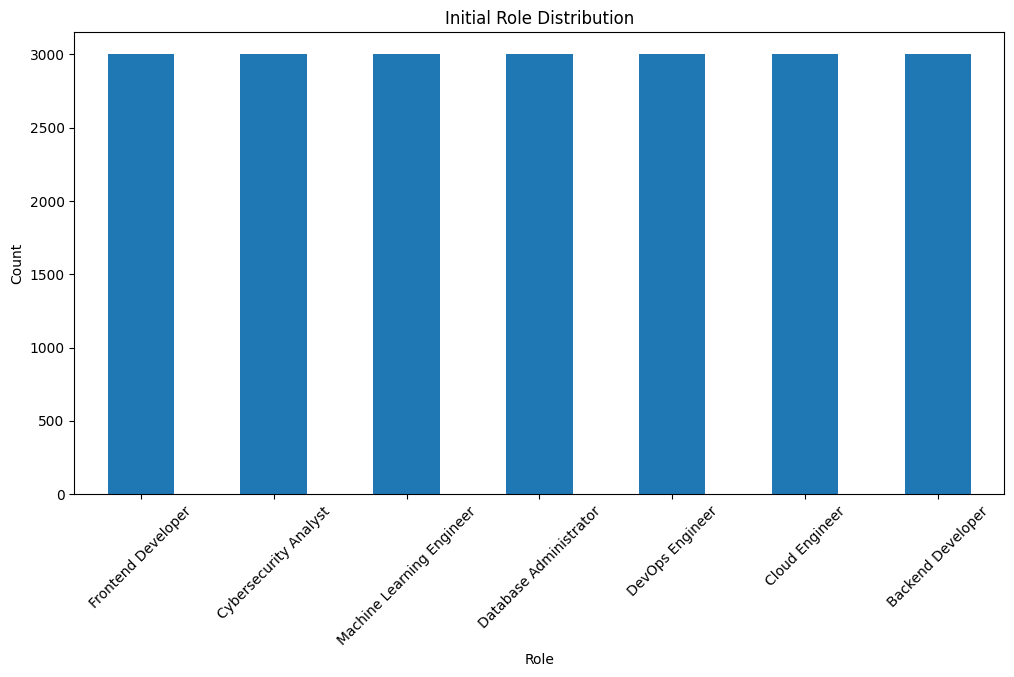


Initial Role Distribution Plot Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/initial_role_distribution.png

REMOVING DUPLICATES

Rows Before Duplicate Removal : 21000
Rows After Duplicate Removal  : 8673
Duplicates Removed            : 12327


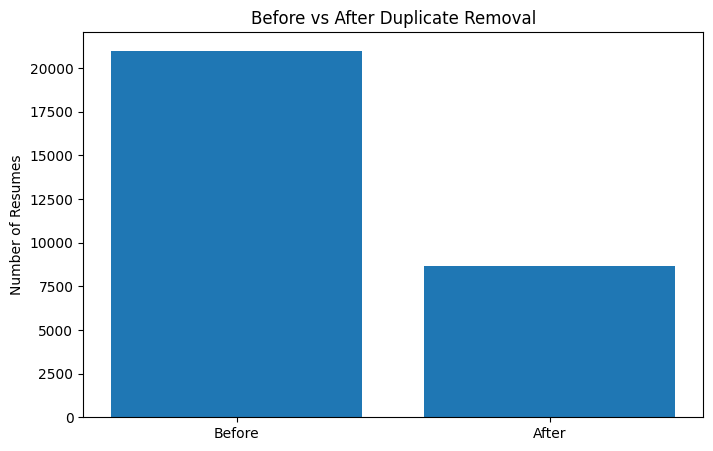


Duplicate Removal Plot Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/duplicate_removal_analysis.png

RESUME LENGTH ANALYSIS

Resume Length Statistics:
count    8673.000000
mean      252.557938
std       188.555098
min        41.000000
25%       139.000000
50%       194.000000
75%       296.000000
max      2029.000000
Name: resume_word_count, dtype: float64


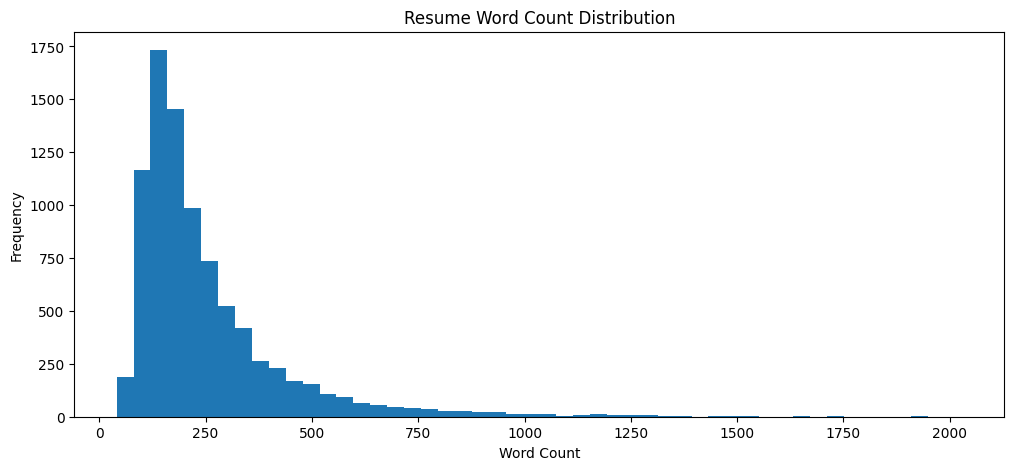


Resume Length Distribution Plot Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/resume_length_distribution.png

FILTERING TINY RESUMES

Minimum Word Threshold : 40
Tiny Resumes Removed   : 0

FILTERING HUGE RESUMES

Maximum Word Threshold : 1200
Huge Resumes Removed   : 51


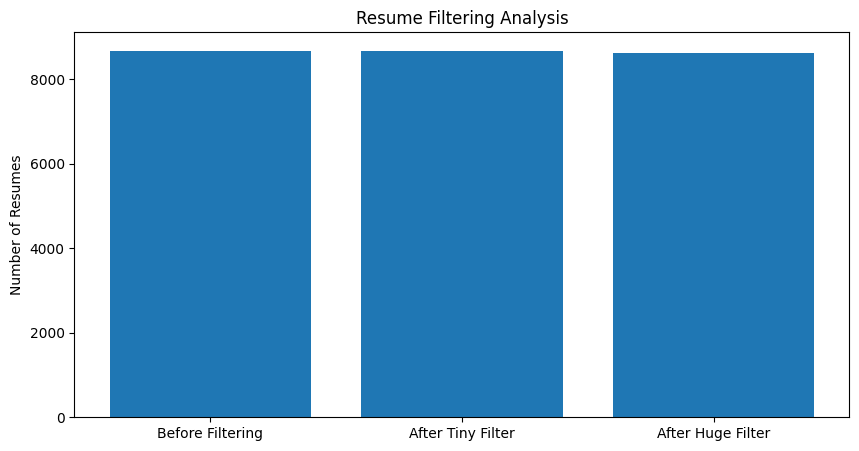


Filtering Analysis Plot Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/resume_filtering_analysis.png

FINAL ROLE DISTRIBUTION
dominant_role
Frontend Developer           2437
Database Administrator       2365
Cybersecurity Analyst        2276
Cloud Engineer                826
Backend Developer             527
DevOps Engineer               144
Machine Learning Engineer      47
Name: count, dtype: int64


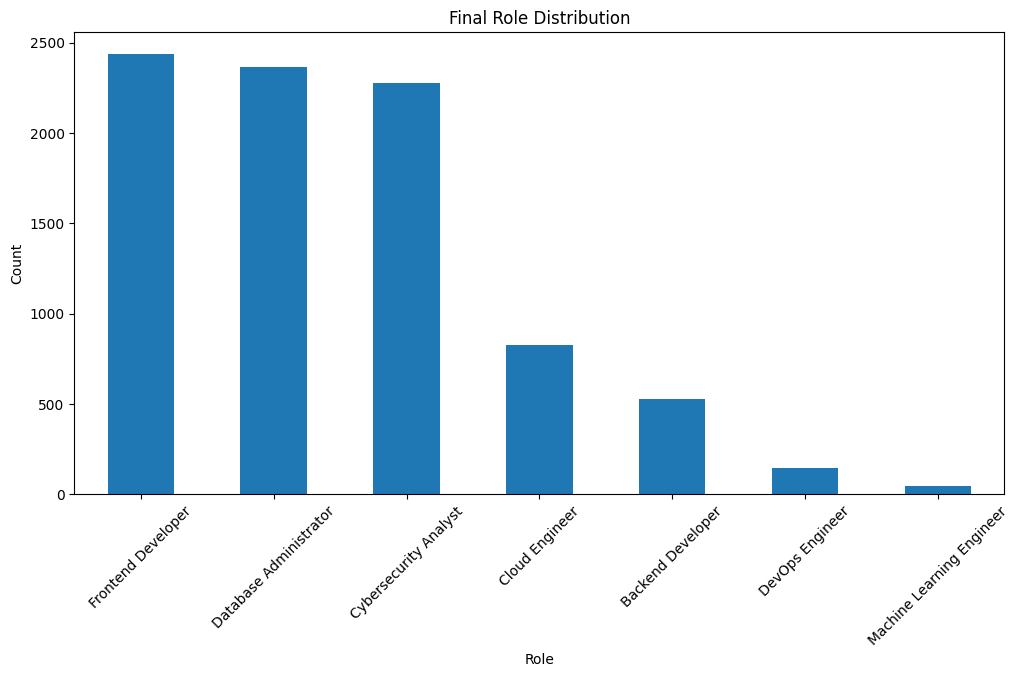


Final Role Distribution Plot Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/final_role_distribution.png


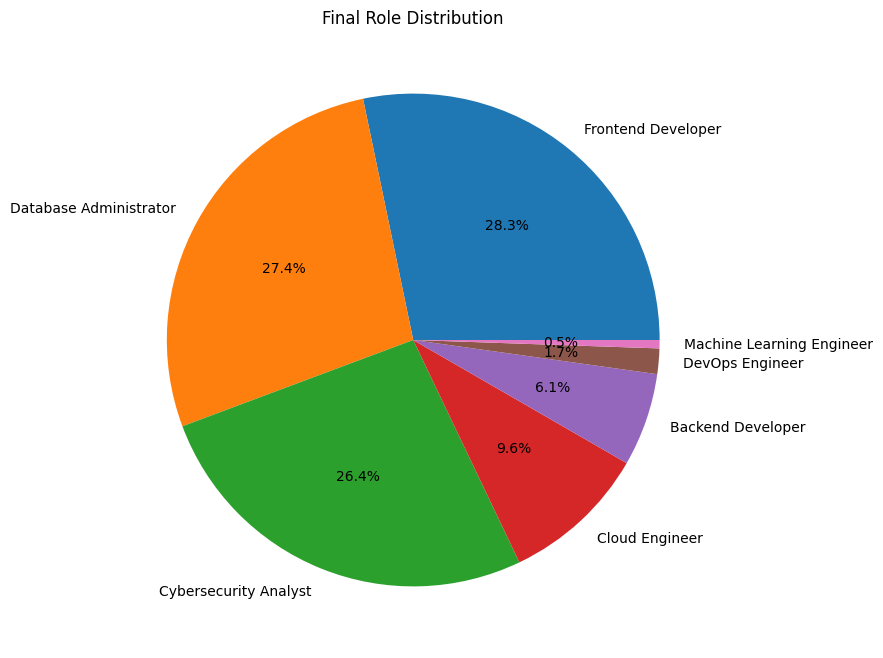


Final Role Pie Chart Saved
/content/drive/MyDrive/NLP_Project-2/Embedding/final_role_distribution_pie_chart.png

FINAL SEMANTIC DATASET

Final Dataset Shape:
(8622, 18)

Final Columns:
['person_id', 'profile_title', 'standardized_role', 'all_abilities', 'all_institutions', 'all_education', 'all_experience_titles', 'all_companies', 'experience_roles', 'all_skills', 'dominant_role', 'projects', 'tools', 'certifications', 'technologies', 'internships', 'semantic_resume', 'resume_word_count']

Missing Values:
person_id                0
profile_title            0
standardized_role        0
all_abilities            0
all_institutions         0
all_education            0
all_experience_titles    0
all_companies            0
experience_roles         0
all_skills               0
dominant_role            0
projects                 0
tools                    0
certifications           0
technologies             0
internships              0
semantic_resume          0
resume_word_count        0
dt

In [4]:
# ============================================================
# NLP PROJECT
# FINAL SEMANTIC DATASET PREPARATION
# ============================================================

# PIPELINE:
# semantic resume
# ↓
# clean text
# ↓
# remove duplicates
# ↓
# filter tiny resumes
# ↓
# filter huge resumes
# ↓
# FINAL SEMANTIC DATASET
# (NO STRICT BALANCING)

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# ============================================================
# INPUT + OUTPUT PATHS
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/final_semantic_resume_dataset.csv"

output_folder = "/content/drive/MyDrive/NLP_Project-2/Embedding"

os.makedirs(output_folder, exist_ok=True)

final_dataset_path = f"{output_folder}/final_semantic_dataset.csv"

# ============================================================
# LOAD DATASET
# ============================================================

print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

df = pd.read_csv(input_path)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nSample Data:")
print(df.head())

# ============================================================
# HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("HANDLING NULL VALUES")
print("=" * 80)

text_columns = [
    'profile_title',
    'standardized_role',
    'all_abilities',
    'all_institutions',
    'all_education',
    'all_experience_titles',
    'all_companies',
    'experience_roles',
    'all_skills',
    'dominant_role',
    'projects',
    'tools',
    'certifications',
    'technologies',
    'internships'
]

for col in text_columns:

    if col in df.columns:

        df[col] = df[col].fillna("")

print("\nNull Values Handled Successfully")

# ============================================================
# CREATE SEMANTIC RESUME
# ============================================================

print("\n" + "=" * 80)
print("CREATING SEMANTIC RESUME")
print("=" * 80)

df['semantic_resume'] = (
    df['profile_title'] + " " +
    df['standardized_role'] + " " +
    df['all_abilities'] + " " +
    df['all_institutions'] + " " +
    df['all_education'] + " " +
    df['all_experience_titles'] + " " +
    df['all_companies'] + " " +
    df['experience_roles'] + " " +
    df['all_skills'] + " " +
    df['dominant_role'] + " " +
    df['projects'] + " " +
    df['tools'] + " " +
    df['certifications'] + " " +
    df['technologies'] + " " +
    df['internships']
)

print("\nSemantic Resume Created Successfully")

print("\nSample Semantic Resume:\n")
print(df['semantic_resume'].iloc[0][:1000])

# ============================================================
# CLEAN TEXT
# ============================================================

print("\n" + "=" * 80)
print("CLEANING TEXT")
print("=" * 80)

def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\\S+", " ", text)

    # remove emails
    text = re.sub(r"\\S+@\\S+", " ", text)

    # remove special characters
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\\s+", " ", text).strip()

    return text

df['semantic_resume'] = df['semantic_resume'].apply(clean_text)

print("\nText Cleaned Successfully")

print("\nSample Cleaned Resume:\n")
print(df['semantic_resume'].iloc[0][:1000])

# ============================================================
# INITIAL ROLE DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("INITIAL ROLE DISTRIBUTION")
print("=" * 80)

initial_role_distribution = df['dominant_role'].value_counts()

print(initial_role_distribution)

# ============================================================
# PLOT 1 - INITIAL ROLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

initial_role_distribution.plot(kind='bar')

plt.title("Initial Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

initial_plot_path = f"{output_folder}/initial_role_distribution.png"

plt.savefig(initial_plot_path)

plt.show()

print("\nInitial Role Distribution Plot Saved")
print(initial_plot_path)

# ============================================================
# REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 80)
print("REMOVING DUPLICATES")
print("=" * 80)

before_duplicates = df.shape[0]

df = df.drop_duplicates(
    subset=['semantic_resume']
)

after_duplicates = df.shape[0]

duplicates_removed = before_duplicates - after_duplicates

print(f"\nRows Before Duplicate Removal : {before_duplicates}")
print(f"Rows After Duplicate Removal  : {after_duplicates}")
print(f"Duplicates Removed            : {duplicates_removed}")

# ============================================================
# PLOT 2 - DUPLICATE REMOVAL ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before', 'After'],
    [before_duplicates, after_duplicates]
)

plt.title("Before vs After Duplicate Removal")
plt.ylabel("Number of Resumes")

duplicate_plot_path = f"{output_folder}/duplicate_removal_analysis.png"

plt.savefig(duplicate_plot_path)

plt.show()

print("\nDuplicate Removal Plot Saved")
print(duplicate_plot_path)

# ============================================================
# CALCULATE RESUME WORD COUNT
# ============================================================

print("\n" + "=" * 80)
print("RESUME LENGTH ANALYSIS")
print("=" * 80)

df['resume_word_count'] = df['semantic_resume'].apply(
    lambda x: len(str(x).split())
)

print("\nResume Length Statistics:")
print(df['resume_word_count'].describe())

# ============================================================
# PLOT 3 - RESUME LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

plt.hist(
    df['resume_word_count'],
    bins=50
)

plt.title("Resume Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

length_distribution_path = f"{output_folder}/resume_length_distribution.png"

plt.savefig(length_distribution_path)

plt.show()

print("\nResume Length Distribution Plot Saved")
print(length_distribution_path)

# ============================================================
# FILTER TINY RESUMES
# ============================================================

print("\n" + "=" * 80)
print("FILTERING TINY RESUMES")
print("=" * 80)

MIN_WORDS = 40

before_tiny_filter = df.shape[0]

df = df[
    df['resume_word_count'] >= MIN_WORDS
]

after_tiny_filter = df.shape[0]

tiny_removed = before_tiny_filter - after_tiny_filter

print(f"\nMinimum Word Threshold : {MIN_WORDS}")
print(f"Tiny Resumes Removed   : {tiny_removed}")

# ============================================================
# FILTER HUGE RESUMES
# ============================================================

print("\n" + "=" * 80)
print("FILTERING HUGE RESUMES")
print("=" * 80)

MAX_WORDS = 1200

before_huge_filter = df.shape[0]

df = df[
    df['resume_word_count'] <= MAX_WORDS
]

after_huge_filter = df.shape[0]

huge_removed = before_huge_filter - after_huge_filter

print(f"\nMaximum Word Threshold : {MAX_WORDS}")
print(f"Huge Resumes Removed   : {huge_removed}")

# ============================================================
# PLOT 4 - FILTERING ANALYSIS
# ============================================================

filtering_labels = [
    'Before Filtering',
    'After Tiny Filter',
    'After Huge Filter'
]

filtering_values = [
    before_tiny_filter,
    after_tiny_filter,
    after_huge_filter
]

plt.figure(figsize=(10, 5))

plt.bar(
    filtering_labels,
    filtering_values
)

plt.title("Resume Filtering Analysis")
plt.ylabel("Number of Resumes")

filtering_plot_path = f"{output_folder}/resume_filtering_analysis.png"

plt.savefig(filtering_plot_path)

plt.show()

print("\nFiltering Analysis Plot Saved")
print(filtering_plot_path)

# ============================================================
# FINAL ROLE DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("FINAL ROLE DISTRIBUTION")
print("=" * 80)

final_role_distribution = df['dominant_role'].value_counts()

print(final_role_distribution)

# ============================================================
# PLOT 5 - FINAL ROLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

final_role_distribution.plot(kind='bar')

plt.title("Final Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

final_distribution_path = f"{output_folder}/final_role_distribution.png"

plt.savefig(final_distribution_path)

plt.show()

print("\nFinal Role Distribution Plot Saved")
print(final_distribution_path)

# ============================================================
# PLOT 6 - FINAL ROLE PIE CHART
# ============================================================

plt.figure(figsize=(8, 8))

final_role_distribution.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Final Role Distribution")

plt.ylabel("")

pie_chart_path = f"{output_folder}/final_role_distribution_pie_chart.png"

plt.savefig(pie_chart_path)

plt.show()

print("\nFinal Role Pie Chart Saved")
print(pie_chart_path)

# ============================================================
# FINAL DATASET ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("FINAL SEMANTIC DATASET")
print("=" * 80)

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFinal Role Distribution:")
print(df['dominant_role'].value_counts())

print("\nSample Final Resume:\n")
print(df['semantic_resume'].iloc[0][:1000])

# ============================================================
# SAVE FINAL DATASET
# ============================================================

print("\n" + "=" * 80)
print("SAVING FINAL SEMANTIC DATASET")
print("=" * 80)

df.to_csv(
    final_dataset_path,
    index=False
)

print("\nFinal Semantic Dataset Saved Successfully")

print("\nSaved Path:")
print(final_dataset_path)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"""

COMPLETED PHASES:

1. Loaded Dataset
2. Handled Missing Values
3. Created Semantic Resume
4. Cleaned Resume Text
5. Removed Duplicate Resumes
6. Filtered Tiny Resumes
7. Filtered Huge Resumes
8. Generated Dataset Analysis
9. Generated Visualization Plots
10. Saved Final Semantic Dataset

FINAL OUTPUT FILE:

final_semantic_dataset.csv

GENERATED PLOTS:

1. initial_role_distribution.png
2. duplicate_removal_analysis.png
3. resume_length_distribution.png
4. resume_filtering_analysis.png
5. final_role_distribution.png
6. final_role_distribution_pie_chart.png

OUTPUT LOCATION:

{output_folder}

""")